Nama : Lusia Clara Sianturi

NIM : 2304010019

# **Housing Prices Dataset**

**Konteks Data**

Dataset yang digunakan merupakan data harga rumah yang bertujuan untuk memprediksi variabel price sebagai target. Setiap data merepresentasikan satu rumah dengan berbagai fitur seperti area, bedrooms, bathrooms, stories, serta fasilitas (_mainroad_, _airconditioning_, _dll_) dan kondisi interior (_furnishingstatus_).



Dataset ini terdiri dari data numerik dan kategorikal tanpa missing values, namun memiliki variasi nilai yang cukup besar. Oleh karena itu, diperlukan proses pre-processing agar data siap digunakan dalam model machine learning.

### **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### **Load Data**

In [ ]:
df = pd.read_csv('/content/Housing.csv')

# Cek data awal
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


Output menampilkan 5 data pertama yang memberikan gambaran awal struktur dataset. Terlihat adanya kombinasi variabel numerik dan kategorikal.

### **Data Understanding**

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

Hasil menunjukkan jumlah data lengkap tanpa missing values. Variabel bertipe _object_ menandakan adanya data kategorikal yang perlu diubah menjadi numerik. Statistik deskriptif menunjukkan adanya variasi nilai yang cukup besar, sehingga perlu dilakukan scaling.

### **Visualisasi Awal Distribusi Data**

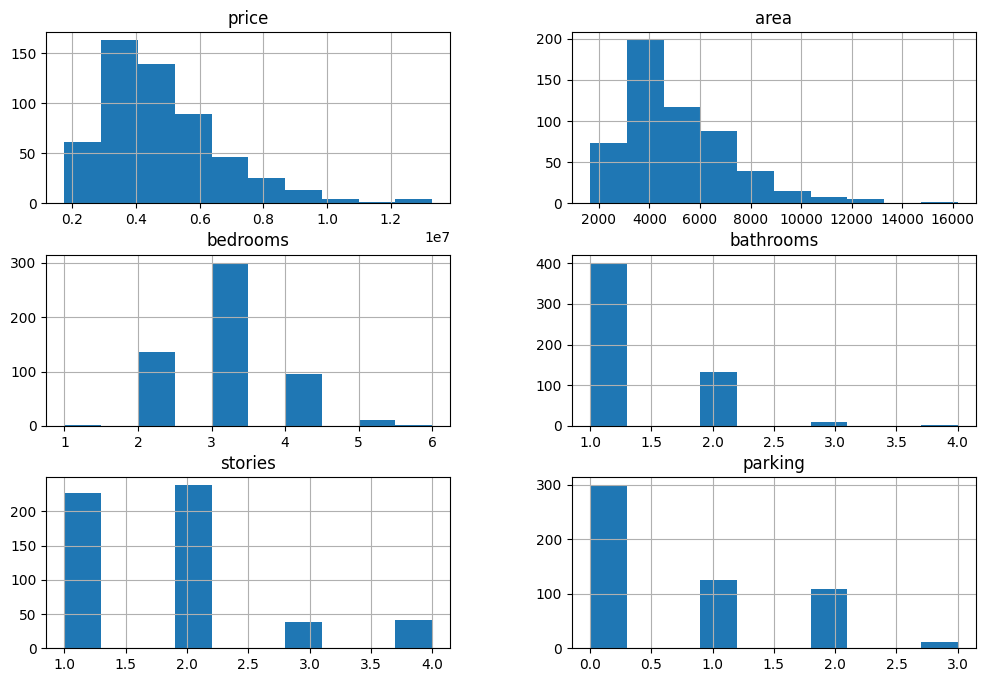

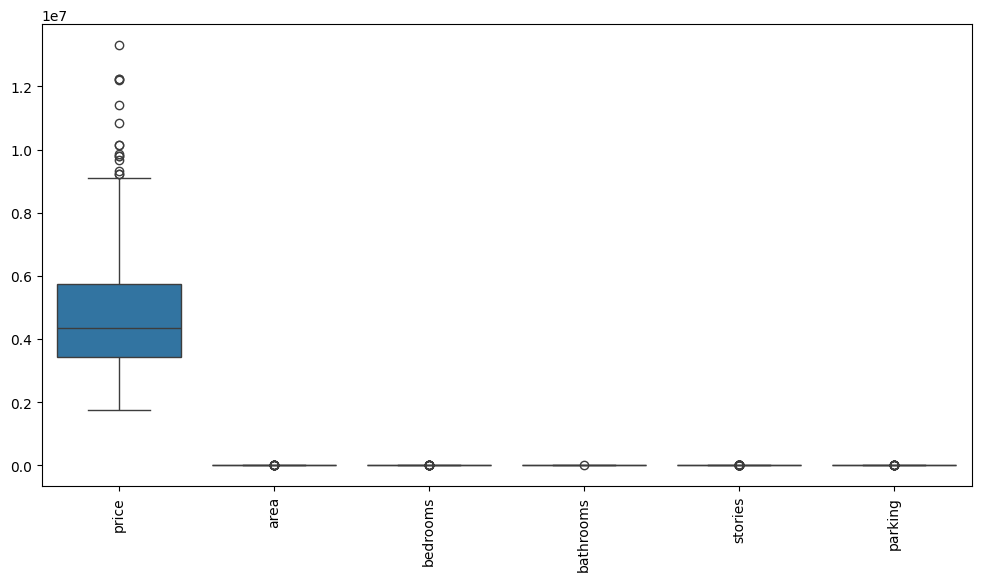

In [ ]:
# Histogram
df.hist(figsize=(12,8))
plt.show()

# Boxplot (outlier)
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

Histogram menunjukkan distribusi masing-masing variabel numerik. Beberapa variabel terlihat tidak berdistribusi normal, yang mengindikasikan kemungkinan adanya skewness atau outlier.

Boxplot menunjukkan adanya beberapa nilai ekstrem (outlier) pada variabel price, yang dapat memengaruhi performa model jika tidak ditangani.

### **Data Cleaning**

In [ ]:
# Hapus duplikat
df = df.drop_duplicates()


Hasil menunjukkan tidak terdapat data duplikat, sehingga dataset tetap digunakan tanpa perubahan.

### **Encoding Data Kategorikal**

In [ ]:
# Ubah yes/no menjadi 1/0
binary_cols = ['mainroad','guestroom','basement','hotwaterheating',
               'airconditioning','prefarea']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes':1, 'no':0})

# One-hot encoding hanya jika kolom ada
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Cek hasil
print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3       NaN        NaN   
1  12250000  8960         4          4        4       NaN        NaN   
2  12250000  9960         3          2        2       NaN        NaN   
3  12215000  7500         4          2        2       NaN        NaN   
4  11410000  7420         4          1        2       NaN        NaN   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0       NaN              NaN              NaN        2       NaN   
1       NaN              NaN              NaN        3       NaN   
2       NaN              NaN              NaN        2       NaN   
3       NaN              NaN              NaN        3       NaN   
4       NaN              NaN              NaN        2       NaN   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

Variabel kategorikal berhasil diubah menjadi numerik. Dataset kini sepenuhnya berbentuk angka.

### **Headmap Korelasi Antar Variabel**

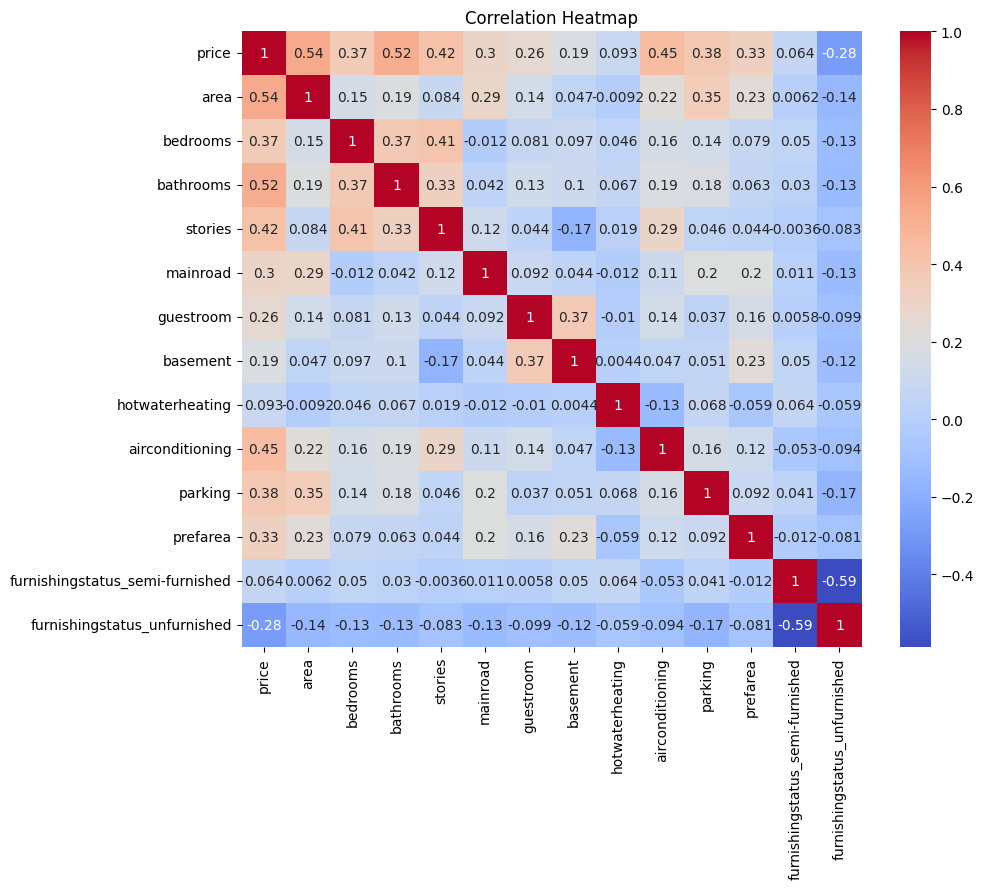

In [74]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Headmap menunjukkan hubungan antar variabel. Variabel seperti area memiliki korelasi cukup kuat dengan price, sehingga berpengaruh dalam prediksi.

### **Scatter Plot (Area vs Price)**

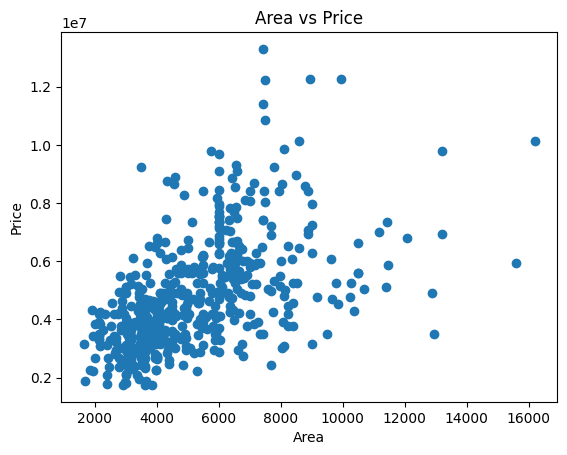

In [75]:
plt.scatter(df['area'], df['price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

Scatter plot menunjukkan hubungan positif antara luas rumah dan harga, yang mengindikasikan bahwa semakin besar luas rumah, semakin tinggi harganya.

### **Feature Selection**

In [79]:
X = df.drop('price', axis=1)
y = df['price']


Variabel target (price) telah dipisahkan dari fitur. Hal ini penting untuk memastikan proses pelatihan model berjalan dengan benar tanpa kebocoran data.

### **Feature Scaling**

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


Hasil scaling menunjukkan bahwa seluruh variabel telah berada pada skala yang sama. Hal ini penting agar tidak ada fitur yang mendominasi model karena perbedaan skala.

### **Distribusi Setelah Scaling**

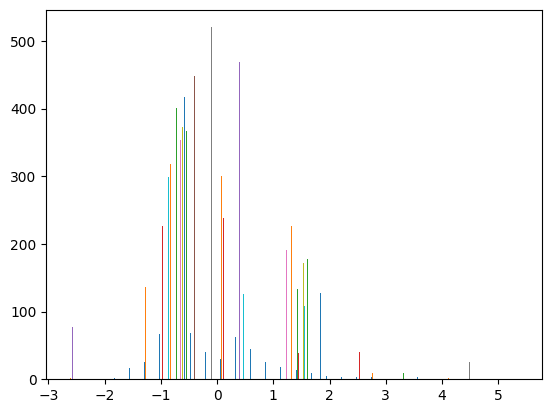

In [84]:
plt.hist(X_scaled, bins=30)
plt.show()

Distribusi data setelah scaling terlihat lebih seragam, yang menandakan bahwa data telah dinormalisasi dengan baik.

### **Split Data**

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (436, 13)
Test size: (109, 13)


Dataset dibagi menjadi data training dan testing. Pembagian ini memungkinkan evaluasi model diakukan secara objektif.

### **Modeling**

In [82]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model dilatih menggunakan data training dan menghasilkan prediksi harga rumah berdasarkan data testing.

### **Visualisasi Hasil**

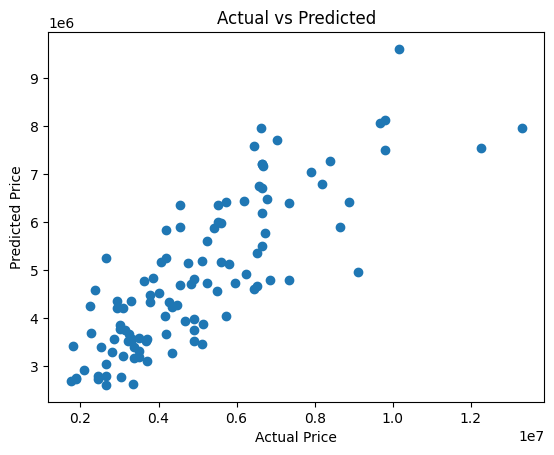

In [83]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

Grafik menunjukkan perbandingan antara nilai aktual dan prediksi. Semakin mendekati garis diagonal, semakin baik performa model dalam memprediksi harga.

### **Kesimpulan**

Secara keseluruhan, proses pre-processing dimulai dari pemahaman data, pembersihan, transformasi, hingga normalisasi berhasil menghasilkan dataset yang siap digunakan dalam pemodelan machine learning. Visualisasi yang dilakukan membantu dalam memahami distribusi data, mendeteksi outlier, serta melihat hubungan antar variabel. Dengan data yang telah diproses dengan baik, model yang dihasilkan menjadi lebih optimal dan akurat dalam melakukan prediksi.